[![preview notebook](https://img.shields.io/static/v1?label=render%20on&logo=github&color=87ce3e&message=GitHub)](https://github.com/open-atmos/PySDM/blob/main/examples/PySDM_examples/Arabas_and_Pawlowska_2011/fig_1.ipynb)
[![launch on mybinder.org](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/open-atmos/PySDM.git/main?urlpath=lab/tree/examples/PySDM_examples/Arabas_and_Pawlowska_2011/fig_1.ipynb)
[![launch on Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/open-atmos/PySDM/blob/main/examples/PySDM_examples/Arabas_and_Pawlowska_2011/fig_1.ipynb)

In [34]:
import os, sys

from PySDM_examples.Arabas_and_Pawlowska_2011 import settings

os.environ['NUMBA_THREADING_LAYER'] = 'workqueue'  # PySDM & PyMPDATA don't work with TBB; OpenMP has extra dependencies on macOS
if 'google.colab' in sys.modules:
    !pip --quiet install open-atmos-jupyter-utils
    from open_atmos_jupyter_utils import pip_install_on_colab
    pip_install_on_colab('PySDM-examples', 'PySDM')

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from   PySDM.physics import si
from PySDM_examples.Arabas_and_Pawlowska_2011 import Simulation, Settings

settings = Settings()
simulation = Simulation(settings)

particulator = simulation.particulator
mode_id = simulation.mode_id
formulae = settings.formulae

multiplicity = particulator.attributes["multiplicity"].to_ndarray()
weights = multiplicity / (settings.mass_of_dry_air / si.mg)

dry_volume = particulator.attributes["dry volume"].to_ndarray()
dry_radius_um = formulae.trivia.radius(volume=dry_volume) / si.um

wet_radius_initial_um = particulator.attributes["radius"].to_ndarray() / si.um

output = simulation.run()
wet_radius_final_um = simulation.particulator.attributes["radius"].to_ndarray() / si.um

Text(0.5, 0.01, 'radius [μm]')

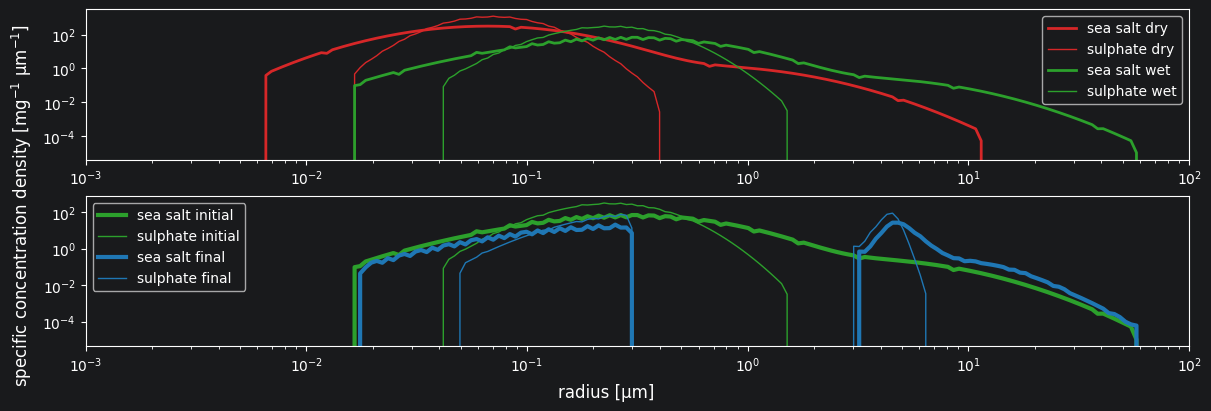

In [36]:
sea_salt_mask = mode_id == 0
sulphate_mask = mode_id == 1

bins = np.logspace(-3,2,200)

def spec(radius_um, w, b):
    hist, edges = np.histogram(radius_um, bins=b, weights=w)
    return np.sqrt(edges[1:] * edges[:-1]), hist / np.diff(edges)

r_dry_ss, y_dry_ss = spec(dry_radius_um[sea_salt_mask], weights[sea_salt_mask], bins)
r_dry_su, y_dry_su = spec(dry_radius_um[sulphate_mask], weights[sulphate_mask], bins)

r_wet0_ss, y_wet0_ss = spec(wet_radius_initial_um[sea_salt_mask], weights[sea_salt_mask], bins)
r_wet0_su, y_wet0_su = spec(wet_radius_initial_um[sulphate_mask],weights[sulphate_mask], bins)

r_wetf_ss, y_wetf_ss = spec(wet_radius_final_um[sea_salt_mask], weights[sea_salt_mask], bins)
r_wetf_su, y_wetf_su = spec(wet_radius_final_um[sulphate_mask], weights[sulphate_mask], bins)

fig, (ax1, ax2) = plt.subplots(2,1,figsize=(12,4), constrained_layout=True)

ax1.plot(r_dry_ss, y_dry_ss, label="sea salt dry", color="tab:red", linewidth=2)
ax1.plot(r_dry_su, y_dry_su, label="sulphate dry", color="tab:red", linewidth=1)
ax1.plot(r_wet0_ss, y_wet0_ss, label="sea salt wet", color="tab:green", linewidth=2)
ax1.plot(r_wet0_su, y_wet0_su, label="sulphate wet", color="tab:green", linewidth=1)

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlim(1e-3, 1e2)

ax1.legend()

ax2.plot(r_wet0_ss, y_wet0_ss, label="sea salt initial", color="tab:green", linewidth=3)
ax2.plot(r_wet0_su, y_wet0_su, label="sulphate initial", color="tab:green", linewidth=1)
ax2.plot(r_wetf_ss, y_wetf_ss, label="sea salt final", color="tab:blue", linewidth=3)
ax2.plot(r_wetf_su, y_wetf_su, label="sulphate final", color="tab:blue", linewidth=1)

ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlim(1e-3, 1e2)

ax2.legend()

fig.supylabel("specific concentration density [mg$^{-1}$ μm$^{-1}$]")
fig.supxlabel("radius [μm]")